# Session 3 — Protein inference and interpretation in human lymph node

## Goal

Apply a pretrained DGAT model to the transcriptome-only 10x Genomics Visium human lymph node dataset (`V1_Human_Lymph_Node`) to infer spatial protein abundance by integrating transcriptomic profiles with spatial context. We then examine whether the inferred protein landscapes capture biologically meaningful germinal-center organization using marker maps, predicted-protein clustering, global Moran's I, and pairwise bivariate Moran's I.

**Every protein value analyzed in this notebook is inferred rather than experimentally measured.** The default participant workflow uses organizer-validated, precomputed DGAT predictions. Because this lymph-node dataset does not include matched protein measurements, the analyses provide indirect biological and spatial evaluation rather than direct protein-level validation. Spatial coherence and co-localization do not by themselves demonstrate prediction accuracy, direct interaction, signaling, or causality.


In [1]:
REQUIREMENTS = [('anndata', 'anndata==0.11.4'), ('scanpy', 'scanpy==1.11.5'), ('seaborn', 'seaborn==0.13.2'), ('igraph', 'igraph==0.11.8'), ('leidenalg', 'leidenalg==0.10.2'), ('networkx', 'networkx==3.4.2'), ('scikit-learn', 'scikit-learn==1.7.2')]

from pathlib import Path
from importlib.metadata import PackageNotFoundError, version as package_version
import importlib, importlib.util, json, os, shutil, subprocess, sys

in_colab = importlib.util.find_spec("google.colab") is not None and Path("/content").is_dir()
if in_colab:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    repo_dir = Path("/content/ECCB-2026-Tutorial")
    tutorial_root = repo_dir / "hands-on_tutorial"
    if not (tutorial_root / "src" / "dgat_tutorial").is_dir():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/osmanbeyoglulab/ECCB-2026-Tutorial.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", "main"], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "reset", "--hard", "origin/main"], check=True)

    drive_root = Path("/content/drive/MyDrive/ECCB2026")
    manifest_path = drive_root / "asset_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"Missing {manifest_path}; run Session 0.")
    manifest = json.loads(manifest_path.read_text())
    drive_data = drive_root / "assets/DGAT_assets/data"
    local_data = tutorial_root / "external/DGAT_assets/data"
    local_data.mkdir(parents=True, exist_ok=True)
    session3_files = (
        "V1_Human_Lymph_Node_filtered_feature_bc_matrix.h5",
        "V1_Human_Lymph_Node_spatial.tar.gz",
        "V1_Human_Lymph_Node_manual_GC_annot.csv",
        "V1_Human_Lymph_Node_DGAT_predicted_proteins.csv",
        "V1_Human_Lymph_Node_DGAT_predicted_proteins.metadata.json",
    )
    for filename in session3_files:
        source, destination = drive_data / filename, local_data / filename
        expected = manifest["files"][filename]["bytes"]
        if not source.is_file() or source.stat().st_size != expected:
            raise IOError(f"Invalid Drive asset: {source}")
        if not destination.is_file() or destination.stat().st_size != expected:
            shutil.copy2(source, destination)
    source_spatial, destination_spatial = drive_data / "spatial", local_data / "spatial"
    if not source_spatial.is_dir():
        raise FileNotFoundError(f"Missing {source_spatial}")
    if destination_spatial.exists():
        shutil.rmtree(destination_spatial)
    shutil.copytree(source_spatial, destination_spatial)
    os.environ["DGAT_TUTORIAL_STATE_DIR"] = str(drive_root / "state")

    dgat_dir = tutorial_root / "external/DGAT"
    if not (dgat_dir / "resources/common_gene_11535.txt").is_file():
        dgat_dir.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/osmanbeyoglulab/DGAT.git", str(dgat_dir)], check=True)

    def package_needs_install(package_spec):
        package_name, expected_version = package_spec.split("==", maxsplit=1)
        try:
            return package_version(package_name) != expected_version
        except PackageNotFoundError:
            return True

    missing = [spec for _, spec in REQUIREMENTS if package_needs_install(spec)]
    if missing:
        wheelhouse = drive_root / "wheelhouse" / f"py{sys.version_info.major}{sys.version_info.minor}"
        online = [sys.executable, "-m", "pip", "install", "-q", *missing]
        if wheelhouse.is_dir() and any(wheelhouse.glob("*.whl")):
            cached = [sys.executable, "-m", "pip", "install", "-q", "--no-index", "--find-links", str(wheelhouse), *missing]
            try:
                subprocess.run(cached, check=True)
            except subprocess.CalledProcessError:
                subprocess.run(online, check=True)
        else:
            subprocess.run(online, check=True)
        importlib.invalidate_caches()
else:
    tutorial_root = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / "src/dgat_tutorial").is_dir()), None)
    if tutorial_root is None:
        raise FileNotFoundError("Could not locate hands-on_tutorial.")
    drive_root = None
    dgat_dir = tutorial_root / "external/DGAT"
    if not (dgat_dir / "resources/common_gene_11535.txt").is_file():
        raise FileNotFoundError("Clone the official DGAT repository under external/DGAT before running Session 3 locally.")

os.chdir(tutorial_root)
if str(tutorial_root / "src") not in sys.path:
    sys.path.insert(0, str(tutorial_root / "src"))
from dgat_tutorial.checkpoints import tutorial_paths, write_checkpoint
paths = tutorial_paths(tutorial_root)
print("Tutorial root:", paths.root)
print("Completed checkpoints:", sorted(p.name for p in paths.checkpoints.glob("session_*/part_*.json")) or "none")


Tutorial root: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial
Completed checkpoints: ['part_1_1.json', 'part_1_2.json', 'part_1_3.json', 'part_2_1.json', 'part_2_2.json', 'part_2_3.json', 'part_2_4.json', 'part_2_5.json', 'part_3_1.json', 'part_3_2.json', 'part_3_3.json']


## Step 1 — Load and align the independent lymph-node workflow (estimated runtime: 15–25 sec)

Session 3 is independent of the Tonsil analyses in Sessions 1–2. It loads the lymph-node RNA count matrix, spatial coordinates, manual germinal-center (GC) annotations, and precomputed DGAT predictions from the assets prepared in Session 0. To reproduce the distributed prediction cohort, the analysis first restricts the RNA matrix to DGAT's 11,535-gene vocabulary and then retains spots with at least 700 detected model genes. All matrices are aligned by barcode, and any annotation mismatch is reported rather than silently discarded.


In [2]:
import hashlib, json, matplotlib.pyplot as plt, networkx as nx, numpy as np, pandas as pd, scanpy as sc, seaborn as sns, warnings
from scipy.cluster.hierarchy import leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from dgat_tutorial.data import load_gc_annotations, load_lymph_node_tutorial_data
from dgat_tutorial.dgat import load_prediction_metadata, load_prediction_table
from dgat_tutorial.alignment import require_exact_identifiers
from dgat_tutorial.plotting import plot_spatial_feature
from dgat_tutorial.processing import calculate_rna_qc_metrics, normalize_total_log1p
from dgat_tutorial.evaluation import symmetric_knn_weights, morans_i_from_weights, bivariate_morans_i_from_weights

asset_data = paths.root / "external/DGAT_assets/data"
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Variable names are not unique.*")
    sample = load_lymph_node_tutorial_data(asset_data)
qc_all = calculate_rna_qc_metrics(sample.transcripts)
model_genes = [gene.strip() for gene in (dgat_dir / "resources/common_gene_11535.txt").read_text().splitlines() if gene.strip()]
present_model_genes = [gene for gene in model_genes if gene in sample.transcripts.columns]
qc_all["model_genes_detected"] = (sample.transcripts.loc[:, present_model_genes] > 0).sum(axis=1)
released_demo2_keep = qc_all["genes_detected"].ge(700)
keep = qc_all["model_genes_detected"].ge(700)
preprocess_first_only = qc_all.index[released_demo2_keep & ~keep]
spots = sample.spots.loc[keep].copy()
rna_counts = sample.transcripts.loc[keep].copy()
qc = qc_all.loc[keep].copy()

gc_source = load_gc_annotations(asset_data / "V1_Human_Lymph_Node_manual_GC_annot.csv")
unmatched_gc = gc_source.index.difference(sample.spots.index)
gc = gc_source.reindex(spots.index, fill_value=False).astype(bool)

prediction_path = asset_data / "V1_Human_Lymph_Node_DGAT_predicted_proteins.csv"
if not prediction_path.is_file() and not in_colab:
    prediction_path = paths.raw_data / prediction_path.name
predicted = load_prediction_table(prediction_path)
metadata = load_prediction_metadata(prediction_path)
if metadata is None or metadata.get("dataset") != "V1_Human_Lymph_Node":
    raise ValueError("Prediction metadata is missing or names a different sample.")
artifact_sha256 = hashlib.sha256(prediction_path.read_bytes()).hexdigest()
if artifact_sha256 != metadata.get("artifact_sha256"):
    raise ValueError("Prediction checksum does not match its provenance sidecar.")
for relative_name, contract in metadata.get("input_manifest", {}).items():
    if not relative_name.startswith("data/"):
        continue
    source_path = asset_data / Path(relative_name).name
    if not source_path.is_file() or source_path.stat().st_size != contract["bytes"]:
        raise IOError(f"Prediction input asset is missing or has the wrong size: {source_path}")
    if hashlib.sha256(source_path.read_bytes()).hexdigest() != contract["sha256"]:
        raise IOError(f"Prediction input checksum mismatch: {source_path}")
require_exact_identifiers(spots.index, rna_counts.index, left_name="QC-retained lymph-node spots", right_name="RNA")
require_exact_identifiers(spots.index, predicted.index, left_name="QC-retained lymph-node spots", right_name="predictions")
if list(predicted.columns) != metadata.get("protein_names"):
    raise ValueError("Prediction proteins do not match the ordered metadata contract.")
if metadata.get("inference_preprocessing") != "fill_genes → preprocess_ST → protein_predict":
    raise ValueError("Prediction provenance does not state the verified inference order.")

markers = ["CD19", "CXCR5", "PDCD1"]
for marker in markers:
    if marker not in rna_counts.columns or marker not in predicted.columns:
        raise KeyError(f"Missing required RNA/predicted-protein marker: {marker}")

print(f"Raw tissue spots: {len(sample.spots):,}")
print(f"Retained at ≥700 detected model genes: {len(spots):,}; excluded: {(~keep).sum():,}")
print(f"Released Demo2 preprocess-first comparison: {int(released_demo2_keep.sum()):,} spots; {len(preprocess_first_only)} are absent from the distributed predictions")
print("Verified distributed order:", metadata["inference_preprocessing"])
print(f"Aligned predictions: {predicted.shape[0]:,} spots × {predicted.shape[1]} proteins")
print(f"GC-positive retained spots: {int(gc.sum()):,}; annotation barcodes absent from tissue: {len(unmatched_gc):,}")
print(metadata["evaluation_scope"])


Raw tissue spots: 4,035
Retained at ≥700 detected model genes: 4,009; excluded: 26
Released Demo2 preprocess-first comparison: 4,014 spots; 5 are absent from the distributed predictions
Verified distributed order: fill_genes → preprocess_ST → protein_predict
Aligned predictions: 4,009 spots × 31 proteins
GC-positive retained spots: 373; annotation barcodes absent from tissue: 0
Indirect anatomical and spatial validation only; no measured lymph-node protein ground truth is available.


## Step 2 — Compare canonical GC mRNA and predicted protein maps (estimated runtime: 3–6 sec)

Lymph-node follicles and germinal centers are specialized niches in which activated B cells proliferate, undergo affinity maturation, and interact with T follicular helper cells. CD19 marks B-cell identity, CXCR5 supports follicular localization, and PDCD1 encodes PD-1, a marker associated with GC T-cell states. Comparing their mRNA and predicted-protein maps therefore provides an exploratory check of whether DGAT recovers expected lymphoid organization.

Compare **spatial locations and patterns**, not colorbar magnitudes: RNA and predicted protein use different transformations and units. Discordance may reflect biological regulation between RNA and protein, low transcript detection, or model error. Without matched measured proteins, these maps cannot establish direct prediction accuracy.


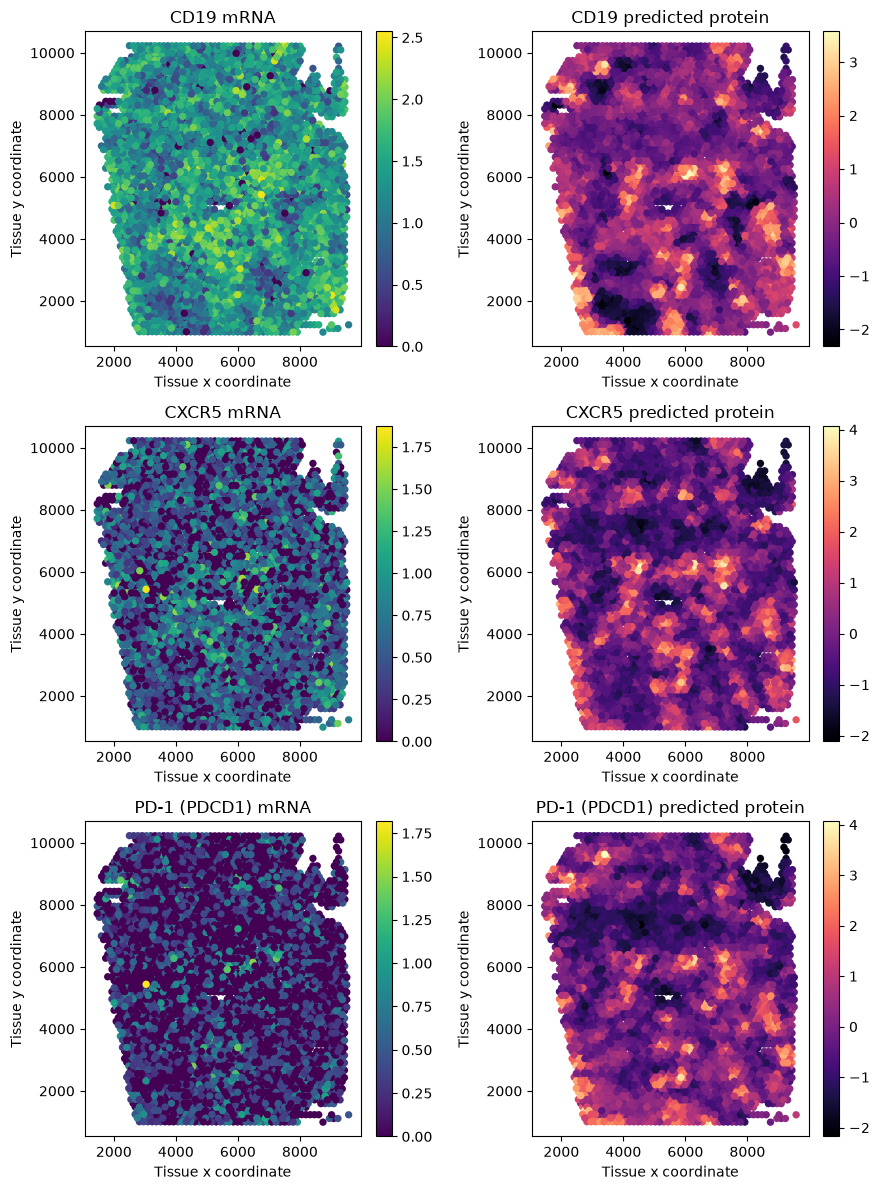

In [3]:
rna_log = normalize_total_log1p(rna_counts)
fig,axes=plt.subplots(3,2,figsize=(9,12))
for row,marker in enumerate(markers):
    label="PD-1 (PDCD1)" if marker=="PDCD1" else marker
    plot_spatial_feature(spots,rna_log[marker],f"{label} mRNA",ax=axes[row,0],cmap="viridis")
    plot_spatial_feature(spots,predicted[marker],f"{label} predicted protein",ax=axes[row,1],cmap="magma")
marker_path=paths.figures/"session03_gc_marker_rna_vs_predicted.png"; fig.tight_layout(); fig.savefig(marker_path,dpi=170); plt.show()


## Step 3 — Cluster spots using all predicted proteins (estimated runtime: 10–20 sec)

To test whether the inferred proteins capture GC-scale tissue organization, spots are clustered using all 31 predicted proteins. This reproduces the released lymph-node `leiden_plot` procedure: build a 10-neighbor graph from the **predicted-protein matrix directly** (`use_rep="X"`) and run Leiden at resolution `0.25` with random seed `0`. No additional standardization or PCA is applied. The previous tutorial added both transformations, changing the neighbor graph and lowering GC-overlap F1. Cluster identifiers are arbitrary labels—not cell types—and plot colors should be interpreted independently of the manual GC colors.


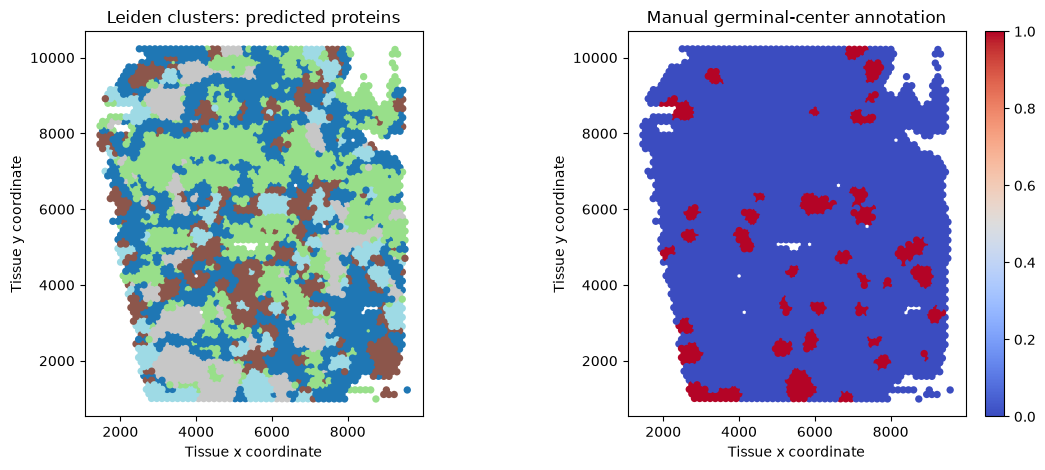

In [4]:
CLUSTER_N_NEIGHBORS, CLUSTER_RESOLUTION, CLUSTER_SEED = 10, 0.25, 0
cluster_adata=sc.AnnData(predicted.to_numpy(dtype=np.float32),obs=pd.DataFrame(index=spots.index),var=pd.DataFrame(index=predicted.columns))
sc.pp.neighbors(cluster_adata,n_neighbors=CLUSTER_N_NEIGHBORS,use_rep="X",random_state=CLUSTER_SEED)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="In the future, the default backend for leiden.*")
    sc.tl.leiden(cluster_adata,resolution=CLUSTER_RESOLUTION,random_state=CLUSTER_SEED,key_added="predicted_protein_cluster",flavor="leidenalg",n_iterations=-1)
clusters=cluster_adata.obs["predicted_protein_cluster"].astype(str).loc[spots.index]
fig,axes=plt.subplots(1,2,figsize=(11,4.8))
cluster_codes=pd.Categorical(clusters).codes
plot_spatial_feature(spots,pd.Series(cluster_codes,index=spots.index),"Leiden clusters: predicted proteins",ax=axes[0],cmap="tab20",add_colorbar=False)
plot_spatial_feature(spots,gc.astype(int),"Manual germinal-center annotation",ax=axes[1],cmap="coolwarm",vmin=0,vmax=1)
cluster_path=paths.figures/"session03_clusters_vs_gc.png"; fig.tight_layout(); fig.savefig(cluster_path,dpi=170); plt.show()


## Step 4 — Quantify cluster overlap with germinal centers (estimated runtime: <1 sec)

Each Leiden cluster is treated in turn as a candidate GC call and compared with the manual annotation. **Precision** is the fraction of spots in that cluster that are annotated as GC, **recall** is the fraction of annotated GC spots recovered by the cluster, and **F1** is their harmonic mean. The cluster with the highest F1 is reported.

With the pinned environment, direct-matrix clustering recovers the paper-level result: the notebook obtains an F1 of approximately `0.830`, consistent with the reported `0.828` (small third-decimal differences can arise across neighbor-graph and Leiden library versions). The former tutorial value of `0.581` resulted from clustering standardized PCA scores instead of the released direct predicted-protein representation, together with implementation/seed differences that altered the graph and partition. Because the best cluster is selected and scored on the same sample, this remains descriptive anatomical concordance rather than independent validation.


In [5]:
rows=[]
for cluster in sorted(clusters.unique(),key=int):
    calls=clusters.eq(cluster)
    rows.append({"cluster":cluster,"spots":int(calls.sum()),"gc_overlap":int((calls&gc).sum()),"accuracy":accuracy_score(gc,calls),"precision":precision_score(gc,calls,zero_division=0),"recall":recall_score(gc,calls,zero_division=0),"f1":f1_score(gc,calls,zero_division=0)})
cluster_metrics=pd.DataFrame(rows).sort_values("f1",ascending=False); best_cluster=str(cluster_metrics.iloc[0]["cluster"])
contingency=pd.crosstab(clusters.rename("cluster"),gc.map({False:"Other",True:"GC"}).rename("annotation"))
metrics_path=paths.results/"session03_cluster_gc_metrics.csv"; contingency_path=paths.results/"session03_cluster_gc_contingency.csv"
cluster_metrics.to_csv(metrics_path,index=False); contingency.to_csv(contingency_path)
print("Best descriptive GC-overlap cluster:",best_cluster); display(cluster_metrics,contingency)
if contingency.to_numpy().sum()!=len(spots): raise AssertionError("Contingency total mismatch")
if not np.isclose(cluster_metrics.iloc[0].f1, 0.828, atol=0.01): raise AssertionError("Direct-matrix GC F1 is not consistent with the published 0.828 reference.")


Best descriptive GC-overlap cluster: 4


,cluster,spots,gc_overlap,accuracy,precision,recall,f1
4,4,410,325,0.966825,0.792683,0.871314,0.830140
2,2,601,33,0.773510,0.054908,0.088472,0.067762
1,1,1167,8,0.619855,0.006855,0.021448,0.010390
0,0,1312,7,0.583188,0.005335,0.018767,0.008309
3,3,519,0,0.777501,0.000000,0.000000,0.000000


annotation,GC,Other
cluster,,
0,7,1305
1,8,1159
2,33,568
3,0,519
4,325,85


## Step 5 — Compare univariate Moran's I (estimated runtime: 4–7 sec)

Biologically organized tissues should show spatially structured—not randomly scattered—marker abundance. Global Moran's I asks whether neighboring spots have similar values: larger positive values indicate stronger spatial autocorrelation, whereas values near zero indicate weak spatial structure. We use the same symmetric six-nearest-neighbor graph for every marker and modality.

`PTPRC_1` and `PTPRC_2` are the panel's two PTPRC/CD45 antibody features: CD45RA and CD45RO, respectively; both are compared with the single `PTPRC` transcript. Stronger predicted-protein Moran's I can reflect genuine recovered tissue structure, model-induced smoothing, or both. It is useful for prioritizing spatially organized predictions, but is not proof of protein accuracy or a statement about anatomical location.


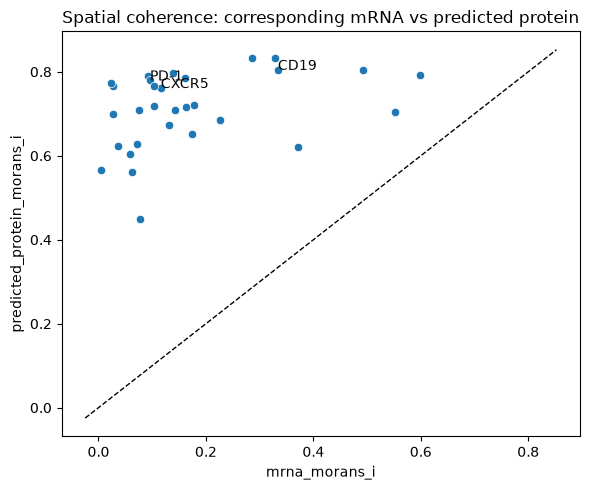

,model_label,panel_target,matched_mrna,interpretation
0,PTPRC_1,CD45RA,PTPRC,naive/RA-associated CD45 isoform antibody feature
1,PTPRC_2,CD45RO,PTPRC,memory/activated RO-associated CD45 isoform an...


,protein,gene,predicted_protein_morans_i,mrna_morans_i,mrna_status,difference
19,ITGAM,ITGAM,0.772759,0.023823,ok,0.748935
1,BCL2,BCL2,0.767133,0.027434,ok,0.739699
9,CD4,CD4,0.789965,0.092716,ok,0.697249
25,PDCD1,PDCD1,0.779409,0.095825,ok,0.683584
7,CD274,CD274,0.700192,0.027059,ok,0.673132
28,PTPRC_2,PTPRC,0.765654,0.102732,ok,0.662922
12,CD8A,CD8A,0.797836,0.139224,ok,0.658612
15,CXCR5,CXCR5,0.761187,0.116061,ok,0.645126
6,CD27,CD27,0.709512,0.075126,ok,0.634386
24,PCNA,PCNA,0.784721,0.161971,ok,0.622750


In [6]:
weights=symmetric_knn_weights(spots,n_neighbors=6)
protein_label_notes=pd.DataFrame([
    {"model_label":"PTPRC_1","panel_target":"CD45RA","matched_mrna":"PTPRC","interpretation":"naive/RA-associated CD45 isoform antibody feature"},
    {"model_label":"PTPRC_2","panel_target":"CD45RO","matched_mrna":"PTPRC","interpretation":"memory/activated RO-associated CD45 isoform antibody feature"},
])
label_notes_path=paths.results/"session03_protein_label_notes.csv"; protein_label_notes.to_csv(label_notes_path,index=False)
rows=[]
for protein in predicted.columns:
    base_gene=protein.rsplit("_",1)[0] if protein.rsplit("_",1)[-1].isdigit() else protein
    gene=base_gene if base_gene in rna_log.columns else base_gene.replace("_","-")
    mrna_i=morans_i_from_weights(rna_log[gene],weights) if gene in rna_log.columns else np.nan
    status="ok" if np.isfinite(mrna_i) else ("undefined: constant-zero mRNA" if gene in rna_log.columns and rna_log[gene].nunique()==1 else "mRNA gene unavailable")
    rows.append({"protein":protein,"gene":gene,"predicted_protein_morans_i":morans_i_from_weights(predicted[protein],weights),"mrna_morans_i":mrna_i,"mrna_status":status})
moran_table=pd.DataFrame(rows); moran_table["difference"]=moran_table["predicted_protein_morans_i"]-moran_table["mrna_morans_i"]
if len(moran_table)!=predicted.shape[1]: raise AssertionError("Univariate Moran table must retain all 31 predicted proteins.")
moran_path=paths.results/"session03_predicted_vs_mrna_morans_i.csv"; moran_table.to_csv(moran_path,index=False)
moran_plot_table=moran_table.dropna(subset=["mrna_morans_i"])
fig,ax=plt.subplots(figsize=(6,5)); sns.scatterplot(data=moran_plot_table,x="mrna_morans_i",y="predicted_protein_morans_i",ax=ax)
lo=min(ax.get_xlim()[0],ax.get_ylim()[0]); hi=max(ax.get_xlim()[1],ax.get_ylim()[1]); ax.plot([lo,hi],[lo,hi],"k--",lw=1)
for marker in markers: 
    row=moran_table[moran_table.protein.eq(marker)]
    if len(row): ax.text(row.mrna_morans_i.iloc[0],row.predicted_protein_morans_i.iloc[0],"PD-1" if marker=="PDCD1" else marker)
ax.set_title("Spatial coherence: corresponding mRNA vs predicted protein")
moran_fig=paths.figures/"session03_morans_i_comparison.png"; fig.tight_layout(); fig.savefig(moran_fig,dpi=170); plt.show(); display(protein_label_notes,moran_table.sort_values("difference",ascending=False,na_position="last"))


## Step 6 — Bivariate Moran's I heatmap and network (estimated runtime: 25–40 sec)

Immune compartments are organized through coordinated cellular programs and shared tissue niches. Bivariate Moran's I measures whether high values of one predicted protein tend to occur near high values of another. The heatmap summarizes all pairs; the network retains `I ≥ 0.70`, matching Figure 5f–g's high-confidence visualization rule, and shows only proteins with at least one retained edge. This removes isolated nodes and makes the B-cell/follicular-associated and T-cell-associated modules easier to see.

The less intuitive CR2–ITGAM association is examined quantitatively below. Its high bivariate Moran's I and same-spot correlation indicate shared predicted follicular-scale geography, which could arise from adjacent B-cell and myeloid populations or correlated model output. It does **not** establish expression in the same cell, molecular binding, signaling, or causality. The same caution applies to every retained edge.


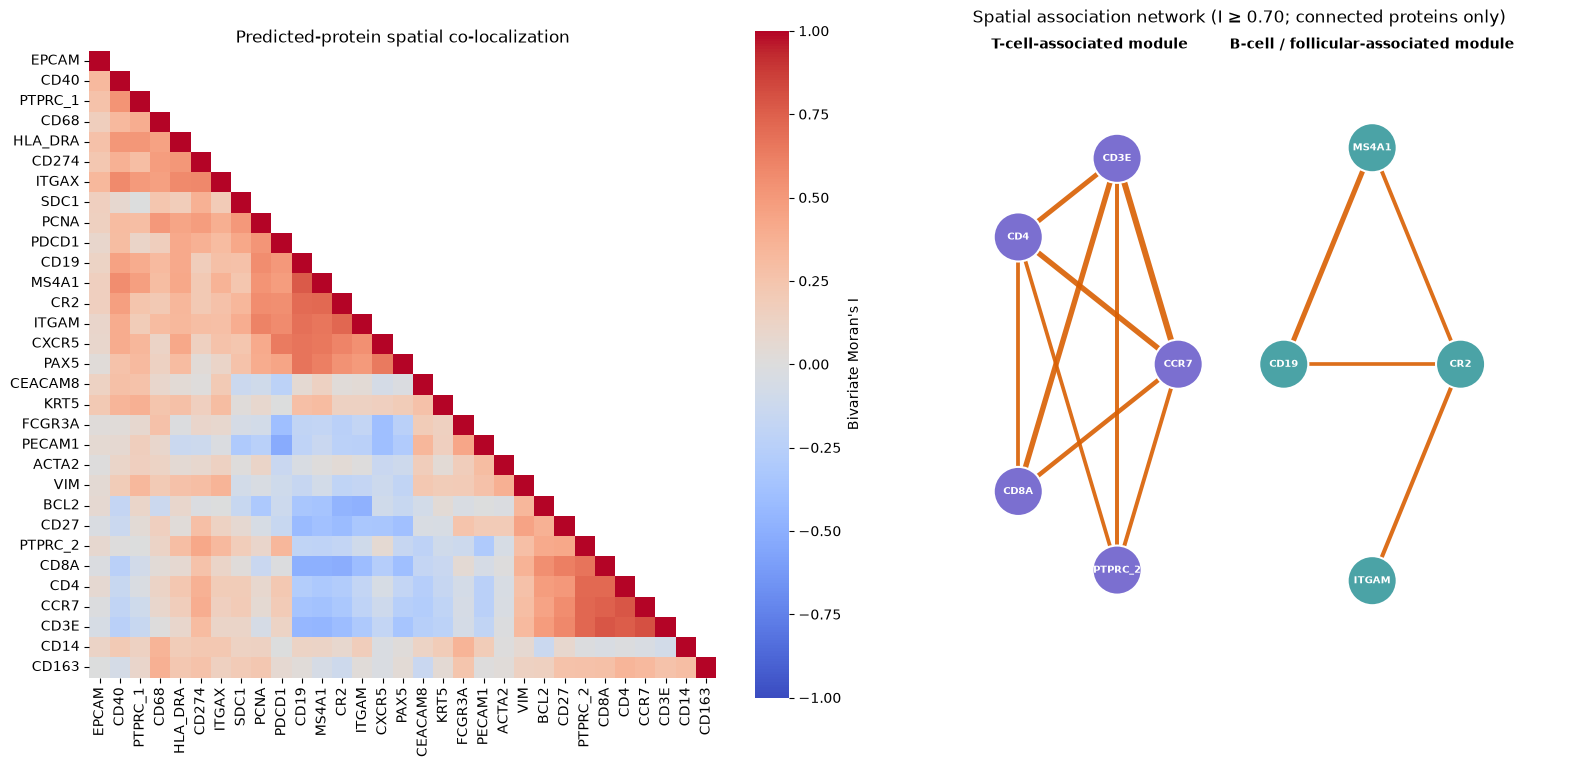

,protein_a,protein_b,bivariate_morans_i
0,CCR7,CD3E,0.809974
1,CCR7,CD4,0.785257
5,CD3E,CD8A,0.784650
10,CD19,MS4A1,0.770037
4,CD3E,CD4,0.761469
2,CCR7,CD8A,0.744853
11,CR2,ITGAM,0.726219
6,CD3E,PTPRC_2,0.721414
3,CCR7,PTPRC_2,0.720087
12,CR2,MS4A1,0.716526


,pair,bivariate_morans_i,same_spot_pearson_r,cr2_univariate_morans_i,itgam_univariate_morans_i,cr2_gc_mean,itgam_gc_mean,interpretation
0,CR2–ITGAM,0.726219,0.904481,0.792915,0.772759,2.158042,2.372951,Shared predicted follicular-scale geography/mo...


In [7]:
proteins=list(predicted.columns); matrix=pd.DataFrame(np.eye(len(proteins)),index=proteins,columns=proteins,dtype=float)
for i,a in enumerate(proteins):
    for j in range(i+1,len(proteins)):
        b=proteins[j]; value=bivariate_morans_i_from_weights(predicted[a],predicted[b],weights); matrix.loc[a,b]=matrix.loc[b,a]=value
if not np.allclose(matrix,matrix.T,equal_nan=True): raise AssertionError("Bivariate matrix is not symmetric")
bivariate_path=paths.results/"session03_bivariate_morans_i.csv"; matrix.to_csv(bivariate_path)
distance=1-matrix.clip(-1,1); distance_values=distance.to_numpy(copy=True); np.fill_diagonal(distance_values,0); order=list(matrix.index[leaves_list(linkage(squareform(distance_values,checks=False),method="average"))])
ordered=matrix.loc[order,order]; mask=np.triu(np.ones_like(ordered,dtype=bool),k=1)
fig,axes=plt.subplots(1,2,figsize=(16,7.5),gridspec_kw={"width_ratios":[1.15,1]})
sns.heatmap(ordered,mask=mask,cmap="coolwarm",center=0,vmin=-1,vmax=1,square=True,ax=axes[0],cbar_kws={"label":"Bivariate Moran's I"}); axes[0].set_title("Predicted-protein spatial co-localization")
threshold=.70; graph=nx.Graph()
for i,a in enumerate(proteins):
    for b in proteins[i+1:]:
        value=float(matrix.loc[a,b])
        if value>=threshold: graph.add_edge(a,b,weight=value)
components=sorted(nx.connected_components(graph),key=lambda nodes:(-len(nodes),sorted(nodes)))
centers=[(-1.15,0),(1.15,0)]; pos={}; node_colors={}
palette=["#7b6fd0","#4ba3a6"]
for component_index,nodes in enumerate(components):
    center=centers[component_index] if component_index<len(centers) else (0,-1.6*component_index)
    component_positions=nx.circular_layout(graph.subgraph(nodes),scale=.72,center=center)
    pos.update(component_positions); node_colors.update({node:palette[component_index%len(palette)] for node in nodes})
widths=[2.5+5*(d["weight"]-threshold)/(1-threshold) for *_,d in graph.edges(data=True)]
nx.draw_networkx_edges(graph,pos,ax=axes[1],width=widths,edge_color="#d95f02",alpha=.9)
nx.draw_networkx_nodes(graph,pos,ax=axes[1],node_size=1250,node_color=[node_colors[n] for n in graph.nodes],edgecolors="white",linewidths=1.5)
nx.draw_networkx_labels(graph,pos,ax=axes[1],font_size=7.2,font_weight="bold",font_color="white")
axes[1].text(-1.15,1.05,"T-cell-associated module",ha="center",fontsize=10,fontweight="bold")
axes[1].text(1.15,1.05,"B-cell / follicular-associated module",ha="center",fontsize=10,fontweight="bold")
axes[1].margins(.20); axes[1].set_title(f"Spatial association network (I ≥ {threshold:.2f}; connected proteins only)"); axes[1].axis("off")
bivariate_fig=paths.figures/"session03_bivariate_heatmap_network.png"; fig.tight_layout(); fig.savefig(bivariate_fig,dpi=180,bbox_inches="tight"); plt.show()
edge_table=pd.DataFrame([{"protein_a":a,"protein_b":b,"bivariate_morans_i":d["weight"]} for a,b,d in graph.edges(data=True)]).sort_values("bivariate_morans_i",ascending=False) if graph.number_of_edges() else pd.DataFrame(columns=["protein_a","protein_b","bivariate_morans_i"])
edges_path=paths.results/"session03_bivariate_network_edges.csv"; edge_table.to_csv(edges_path,index=False)
cr2_itgam_check=pd.DataFrame([{"pair":"CR2–ITGAM","bivariate_morans_i":matrix.loc["CR2","ITGAM"],"same_spot_pearson_r":predicted["CR2"].corr(predicted["ITGAM"]),"cr2_univariate_morans_i":morans_i_from_weights(predicted["CR2"],weights),"itgam_univariate_morans_i":morans_i_from_weights(predicted["ITGAM"],weights),"cr2_gc_mean":predicted.loc[gc,"CR2"].mean(),"itgam_gc_mean":predicted.loc[gc,"ITGAM"].mean(),"interpretation":"Shared predicted follicular-scale geography/model covariance; not direct interaction or same-cell evidence"}])
association_check_path=paths.results/"session03_cr2_itgam_check.csv"; cr2_itgam_check.to_csv(association_check_path,index=False); display(edge_table,cr2_itgam_check)


## Step 7 — Save Session 3 results and discussion prompts (estimated runtime: <1 sec)

This step saves the figures, result tables, interpretation prompts, and completion checkpoint. In Colab, the checkpoint and results are written to the Session 0 Google Drive state directory so they remain available after the runtime ends.

### Discussion questions

1. How do the spatial patterns of CD19, CXCR5, and PD-1 mRNA differ from their predicted proteins?
2. Which predicted-protein cluster best overlaps the manual GC annotation, and what do its precision, recall, and F1 reveal?
3. Which predicted proteins have the strongest spatial autocorrelation, and could this reflect biology, model smoothing, or both?
4. Do the bivariate Moran's I results recover coherent B-cell/follicular and T-cell-associated modules?
5. Which predicted spatial patterns or associations should be prioritized for experimental validation, and what assay would test them?


In [8]:
prompts="""# Lymph-node interpretation prompts\n\n1. How do the spatial patterns of CD19, CXCR5, and PD-1 mRNA differ from their predicted proteins?\n2. Which predicted-protein cluster best overlaps the manual GC annotation, and what do its precision, recall, and F1 reveal?\n3. Which predicted proteins have the strongest spatial autocorrelation, and could this reflect biology, model smoothing, or both?\n4. Do the bivariate Moran's I results recover coherent B-cell/follicular and T-cell-associated modules?\n5. Which predicted spatial patterns or associations should be prioritized for experimental validation, and what assay would test them?\n\nAll proteins are inferred rather than measured. Spatial coherence and co-localization do not establish prediction accuracy, direct interaction, signaling, or causality.\n"""
prompt_path=paths.results/"session03_interpretation_prompts.md"; prompt_path.write_text(prompts)
manifest=write_checkpoint("3.1",[marker_path,cluster_path,metrics_path,contingency_path,moran_path,moran_fig,label_notes_path,bivariate_path,bivariate_fig,edges_path,association_check_path,prompt_path],summary={"sample":"V1_Human_Lymph_Node","spots":len(spots),"clusters":int(clusters.nunique()),"best_gc_cluster":best_cluster,"best_f1":float(cluster_metrics.iloc[0].f1),"cluster_input":"direct predicted-protein matrix","cluster_n_neighbors":CLUSTER_N_NEIGHBORS,"cluster_resolution":CLUSTER_RESOLUTION,"cluster_seed":CLUSTER_SEED,"network_threshold":.70,"network_edges":graph.number_of_edges(),"network_nodes":graph.number_of_nodes()},start=paths.root)
print(prompts); print("Checkpoint:",manifest)


# Lymph-node interpretation prompts

1. How do the spatial patterns of CD19, CXCR5, and PD-1 mRNA differ from their predicted proteins?
2. Which predicted-protein cluster best overlaps the manual GC annotation, and what do its precision, recall, and F1 reveal?
3. Which predicted proteins have the strongest spatial autocorrelation, and could this reflect biology, model smoothing, or both?
4. Do the bivariate Moran's I results recover coherent B-cell/follicular and T-cell-associated modules?
5. Which predicted spatial patterns or associations should be prioritized for experimental validation, and what assay would test them?

All proteins are inferred rather than measured. Spatial coherence and co-localization do not establish prediction accuracy, direct interaction, signaling, or causality.

Checkpoint: /Users/zmengaf/Documents/ECCB tuto/hands-on_tutorial/checkpoints/session_03/part_3_1.json


## Optional reproducibility — rerun full lymph-node inference

This section is **not part of the timed hands-on workflow**. The default analysis uses the organizer-validated precomputed matrix so participants obtain identical results on a free-tier CPU runtime. Enable the flag only with a GPU runtime, additional setup time, and sufficient memory.

The distributed prediction artifact was generated in the verified order `fill_genes → preprocess_ST → protein_predict`; its provenance metadata and 4,009-row barcode contract record that choice. Although the released lymph-node Demo2 example displays `preprocess_ST → fill_genes` (retaining 4,014 spots for this input), the general released ST workflow uses the artifact order. The optional rerun therefore follows the distributed artifact provenance so the main and optional workflows use the same cohort and are directly comparable.


In [9]:
RUN_OPTIONAL_FULL_INFERENCE = False
if not RUN_OPTIONAL_FULL_INFERENCE:
    print("Optional inference skipped. Continue using the validated precomputed matrix.")


Optional inference skipped. Continue using the validated precomputed matrix.


In [10]:
if RUN_OPTIONAL_FULL_INFERENCE:
    optional_specs = ["muon==0.1.7", "mudata==0.3.1", "torch-geometric==2.6.1", "gdown==6.1.0"]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *optional_specs], check=True)
    importlib.invalidate_caches()
    if package_version("mudata") != "0.3.1":
        raise RuntimeError("Expected mudata==0.3.1. Restart the runtime and rerun Session 3.")

    dgat_dir = paths.root / "external/DGAT"
    if not (dgat_dir / "utils/Preprocessing.py").is_file():
        dgat_dir.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/osmanbeyoglulab/DGAT.git", str(dgat_dir)], check=True)
    if in_colab:
        environment = os.environ.copy()
        environment["DGAT_ASSET_DIR"] = str(drive_root / "assets/DGAT_assets")
        environment["DGAT_PRECOMPUTED_DIR"] = str(drive_root / "organizer/lymph_node_prediction_build")
        subprocess.run(["bash", "scripts/download_dgat_assets.sh", "--dataset", "V1_Human_Lymph_Node", "--include-model"], cwd=tutorial_root, env=environment, check=True)

    from anndata import AnnData
    if str(dgat_dir) not in sys.path:
        sys.path.insert(0, str(dgat_dir))
    from utils.Preprocessing import fill_genes, preprocess_ST
    from Model.Train_and_Predict import protein_predict

    common_genes = [x.strip() for x in (dgat_dir / "resources/common_gene_11535.txt").read_text().splitlines() if x.strip()]
    common_proteins = list(predicted.columns)
    adata = AnnData(
        X=sample.transcripts.to_numpy(dtype=np.float32),
        obs=sample.spots.copy(),
        var=pd.DataFrame(index=sample.transcripts.columns.astype(str)),
    )
    adata.obsm["spatial"] = sample.spots[["x", "y"]].to_numpy(float)
    adata.uns["name"] = "V1_Human_Lymph_Node"
    adata = fill_genes(adata, common_genes)
    preprocess_ST(adata)
    model_root = (drive_root / "assets/DGAT_assets/DGAT_pretrained_models" if in_colab else paths.root / "external/DGAT_assets/DGAT_pretrained_models")
    rerun_adata = protein_predict(adata, common_genes, common_proteins, str(model_root), str(paths.processed_data / "pyg_lymph_node_optional"))
    rerun = pd.DataFrame(np.asarray(rerun_adata.X), index=rerun_adata.obs_names, columns=common_proteins)
    require_exact_identifiers(predicted.index, rerun.index, left_name="precomputed spots", right_name="optional rerun spots")
    rerun = rerun.loc[predicted.index, predicted.columns]
    comparison = pd.DataFrame({
        "pearson_r": [predicted[p].corr(rerun[p]) for p in common_proteins],
        "mean_absolute_difference": [float((predicted[p] - rerun[p]).abs().mean()) for p in common_proteins],
    }, index=common_proteins)
    optional_path = paths.results / "session03_optional_inference_comparison.csv"
    comparison.to_csv(optional_path)
    display(comparison)
    print("Optional comparison:", optional_path)


## Checks and limitations

- Re-run from the top and confirm the same direct-matrix Leiden labels and paper-level GC metrics.
- The distributed prediction build uses `fill_genes → preprocess_ST → protein_predict`; Demo2's opposite order is documented above rather than silently mixed into the optional rerun.
- The univariate table retains all 31 predictions. The protein identifier `HLA_DRA` is explicitly matched to the RNA symbol `HLA-DRA`; CEACAM8 mRNA is constant zero here, so its mRNA Moran's I is correctly reported as undefined instead of dropping the protein.
- Constant signals should return undefined Moran's I; shuffled signals should usually approach zero; constructed spatial gradients should be positive.
- All analyzed proteins are inferred rather than experimentally measured, and low transcriptomic coverage can degrade inference.
- Moran statistics depend on the six-neighbor graph, and model smoothing can increase apparent spatial coherence.
- GC overlap measures anatomical concordance within this sample; it is not independent protein-level validation because the best cluster is selected and scored on the same data.
- Spatial co-localization does not establish expression in the same cell, direct molecular interaction, signaling, or causality.
- Multi-method benchmarking, ablation, cross-tissue validation, and immunofluorescence validation are covered in the lecture rather than reproduced here.


## Next steps

Use DGAT predictions to formulate biological hypotheses, then validate prioritized patterns with measured proteins or orthogonal imaging. The tutorial workflow is now complete: Sessions 1–2 use paired tonsil RNA and measured protein for training and evaluation, while Session 3 applies the pretrained model to a transcript-only lymph node for inference and spatial interpretation.
